# Figures for FYR and papers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 1. Coverage map

OCA                  vertex    E/MTG      E/W
SHANWICK         -30.0,61.0     78.5     78.5
SHANWICK         -10.0,61.0     86.9     86.9
SHANWICK         -10.0,54.6     84.6     84.6
SHANWICK         -15.0,54.0     81.6     81.6
SHANWICK         -15.0,51.0     80.3     80.3
SHANWICK          -8.0,51.0     84.5     84.5
SHANWICK          -8.0,45.0     82.7     82.7
SHANWICK         -30.0,45.0     68.2     69.8
                   -> range  68.2-86.9  69.8-86.9

GANDER           -30.0,45.0     68.2     69.8
GANDER           -30.0,61.0     78.5     78.5
GANDER           -40.0,63.0     78.2     78.2
GANDER           -54.0,62.5     82.9     84.5
GANDER           -58.0,65.0     85.7     85.9
GANDER           -65.0,65.0     88.4     88.7
GANDER           -60.0,57.5     83.0     88.2
GANDER           -54.0,54.0     78.3     85.3
GANDER           -51.0,49.0     74.0     83.9
GANDER           -51.0,45.0     71.8     84.0
                   -> range  68.2-88.4  69.8-88.7



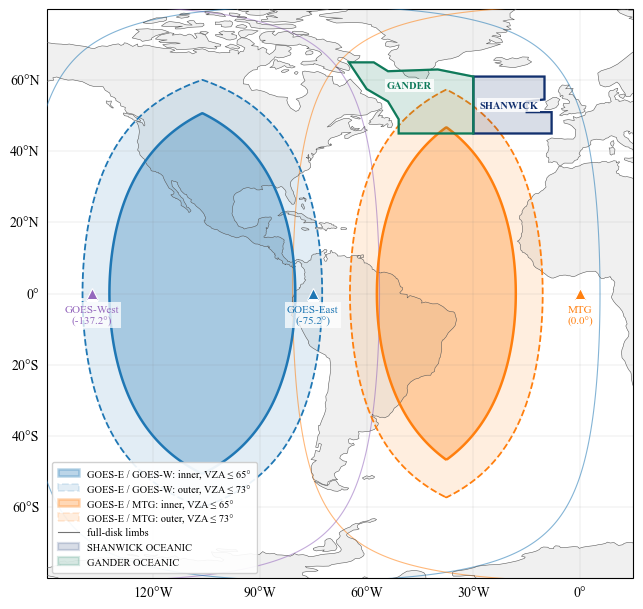

In [43]:
"""Stereo coverage map with the North Atlantic OCAs overlaid."""
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch, Polygon
from matplotlib.lines import Line2D

R_E, R_S = 6371.0, 42164.0
VZA_OUTER, VZA_CORE = 73.0, 65.0
CENTRAL_LON = -65.0

SATS = {"GOES-West": (-137.2, "C4"),
        "GOES-East": (-75.2,  "C0"),
        "MTG":       (0.0,    "C1")}

DMS = lambda d, m=0: d + m / 60.0
SHANWICK = [(-30.0, 61.0), (-10.0, 61.0), (-10.0, DMS(54, 34)), (-15.0, 54.0),
            (-15.0, 51.0), (-8.0, 51.0), (-8.0, 45.0), (-30.0, 45.0)]
E_30W = [(-30.0, 45.0), (-30.0, 61.0)]
GANDER = E_30W + [(-40.0, 63.0), (-54.0, 62.5), (-58.0, 65.0), (-65.0, 65.0),
                  (-60.0, 57.5), (-54.0, 54.0), (-51.0, 49.0), (-51.0, 45.0)]

OCAS = {"SHANWICK OCEANIC": dict(poly=SHANWICK, color="#12306e",
                                 label=(-20.0, 53.0)),
        "GANDER OCEANIC":   dict(poly=GANDER,   color="#0f7a5a",
                                 label=(-48.0, 58.5))}

lon = np.linspace(CENTRAL_LON - 180, CENTRAL_LON + 180, 1441)
lat = np.linspace(-90, 90, 641)
LON, LAT = np.meshgrid(lon, lat)


def vza_field(sat_lon):
    cospsi = np.cos(np.deg2rad(LAT)) * np.cos(np.deg2rad(LON - sat_lon))
    psi = np.arccos(np.clip(cospsi, -1, 1))
    d = np.sqrt(R_S**2 + R_E**2 - 2 * R_S * R_E * cospsi)
    vza = np.degrees(np.arcsin(np.clip(R_S * np.sin(psi) / d, 0, 1)))
    return np.where(cospsi < R_E / R_S, np.nan, vza)


def vza_at(sat_lon, lo, la):
    """Scalar VZA, for annotating the OCAs."""
    cospsi = np.cos(np.deg2rad(la)) * np.cos(np.deg2rad(lo - sat_lon))
    psi = np.arccos(np.clip(cospsi, -1, 1))
    d = np.sqrt(R_S**2 + R_E**2 - 2 * R_S * R_E * cospsi)
    return np.degrees(np.arcsin(np.clip(R_S * np.sin(psi) / d, 0, 1)))


V = {n: vza_field(sl) for n, (sl, _) in SATS.items()}
pairs = {"GOES-E / GOES-W": (np.maximum(V["GOES-East"], V["GOES-West"]), "C0"),
         "GOES-E / MTG":    (np.maximum(V["GOES-East"], V["MTG"]),       "C1")}

fig = plt.figure(figsize=(12, 6.2))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=CENTRAL_LON))
pc = ccrs.PlateCarree()
ax.set_extent([-150, 15, -80, 80], crs=pc)
ax.add_feature(cfeature.LAND, fc="0.94", zorder=0)
ax.add_feature(cfeature.COASTLINE, lw=0.4, ec="0.35", zorder=4)

for label, (pair, col) in pairs.items():
    ax.contourf(LON, LAT, pair, levels=[0, VZA_OUTER], colors=[col],
                alpha=0.13, transform=pc, zorder=1)
    ax.contour(LON, LAT, pair, levels=[VZA_OUTER], colors=[col],
               linewidths=1.3, linestyles="--", transform=pc, zorder=5)
    ax.contourf(LON, LAT, pair, levels=[0, VZA_CORE], colors=[col],
                alpha=0.30, transform=pc, zorder=2)
    ax.contour(LON, LAT, pair, levels=[VZA_CORE], colors=[col],
               linewidths=1.8, transform=pc, zorder=5)

# --- OCAs: closed polygons in lon/lat, drawn as great-circle-free straight
#     edges in PlateCarree (matches how the boundaries are legally defined) ---
for name, d in OCAS.items():
    ax.add_patch(Polygon(d["poly"], closed=True, transform=pc,
                         fc=d["color"], ec=d["color"], alpha=0.16,
                         lw=1.6, zorder=6))
    ax.add_patch(Polygon(d["poly"], closed=True, transform=pc,
                         fc="none", ec=d["color"], lw=1.6, zorder=7))
    ax.text(*d["label"], name.replace(" OCEANIC", ""), fontsize=7.5,
            weight="bold", color=d["color"], ha="center", va="center",
            transform=pc, zorder=8,
            bbox=dict(fc="white", ec="none", alpha=0.8, pad=1.5))

for name, (sl, col) in SATS.items():
    ax.contour(LON, LAT, V[name], levels=[89.5], colors=[col],
               linewidths=0.8, alpha=0.55, transform=pc, zorder=3)
    ax.plot(sl, 0, "^", color=col, ms=9, mec="white", mew=0.8,
            transform=pc, zorder=6)
    ax.text(sl, -3, f"{name}\n({sl:.1f}\u00b0)", ha="center", va="top",
            fontsize=8, color=col, transform=pc, zorder=6,
            bbox=dict(fc="white", ec="none", alpha=0.75, pad=1.5))

handles = []
for label, (_, col) in pairs.items():
    handles += [Patch(fc=col, alpha=0.30, ec=col, lw=1.8,
                      label=f"{label}: inner, VZA \u2264 {VZA_CORE:.0f}\u00b0"),
                Patch(fc=col, alpha=0.13, ec=col, lw=1.3, ls="--",
                      label=f"{label}: outer, VZA \u2264 {VZA_OUTER:.0f}\u00b0")]
handles.append(Line2D([], [], color="0.45", lw=0.8, label="full-disk limbs"))
handles += [Patch(fc=d["color"], alpha=0.16, ec=d["color"], lw=1.6, label=n)
            for n, d in OCAS.items()]
ax.legend(handles=handles, loc="lower left", fontsize=7.5, framealpha=0.92,
          borderpad=0.6, labelspacing=0.45)

gl = ax.gridlines(draw_labels=True, lw=0.3, alpha=0.35, color="0.5")
gl.top_labels = gl.right_labels = False
plt.tight_layout()
plt.savefig("/Users/lewisclark/Documents/python_work/stereo/outputs/coverage_oca.pdf", dpi=200, bbox_inches="tight")

# --- pair VZA over each OCA, for the text ---
print(f"{'OCA':10s} {'vertex':>16s} {'E/MTG':>8s} {'E/W':>8s}")
for name, d in OCAS.items():
    vals_m, vals_w = [], []
    for lo, la in d["poly"]:
        m = max(vza_at(-75.2, lo, la), vza_at(0.0, lo, la))
        w = max(vza_at(-75.2, lo, la), vza_at(-137.2, lo, la))
        vals_m.append(m); vals_w.append(w)
        print(f"{name.split()[0]:10s} {f'{lo:.1f},{la:.1f}':>16s} "
              f"{m:8.1f} {w:8.1f}")
    print(f"{'':10s} {'-> range':>16s} {min(vals_m):5.1f}-{max(vals_m):.1f} "
          f"{min(vals_w):5.1f}-{max(vals_w):.1f}\n")

# Example map panel

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from contrailstereo.config import DEFAULT as cfg, SAT_LON
from contrailstereo.data.caliop import build_scene_table
from contrailstereo.core.retrieve import load_scene, run_scene
from contrailstereo.core.fields import make_sampler
from contrailstereo.geometry import apparent_surface_latlon
from contrailstereo.vis.scene import map_panel

NC_PATH = ("/Users/lewisclark/Documents/python_work/anticyclonic/"
           "data/goes_caliop_contrail_collocations.nc")
scenes, prof_df = build_scene_table(NC_PATH)

si = 8
sd = load_scene(scenes.iloc[si], prof_df, cfg)
rec, pr, extras = run_scene(sd, cfg, do_map=True)

a, b = cfg.match_channels
samp = make_sampler(sd.fields[cfg.sat_east][a], sd.fields[cfg.sat_east][b])
h_ref = rec["h_local"] if np.isfinite(rec["h_local"]) else 11.0
ala, alo = apparent_surface_latlon(extras["glat"], extras["glon"],
                                   h_ref * 1e3, SAT_LON[cfg.sat_east])
btd = samp(ala, alo)

fig = map_panel(extras, pr, rec, si, btd=btd,
                diagnostic_title=False,          # FYR version: no debug text
                save="/Users/lewisclark/Documents/python_work/stereo/outputs/fyr_map_panel_scene8.pdf")


/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/vis/scene.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


# Scatter results

In [4]:
from contrailstereo.validation.metrics import bias_correct_cv, bias_correct_cv_ci
from contrailstereo.vis.summary import *
cv = bias_correct_cv("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv", gate=0.6)
fig = map_scatter_pair("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv", gate=0.6,
                       rmse_corr=0.58,
                       save="/Users/lewisclark/Documents/python_work/stereo/outputs/fyr_scatter_pair.pdf")

# High VZA

In [5]:
from contrailstereo.core.fields import hp_km
from contrailstereo.geometry import km_filters

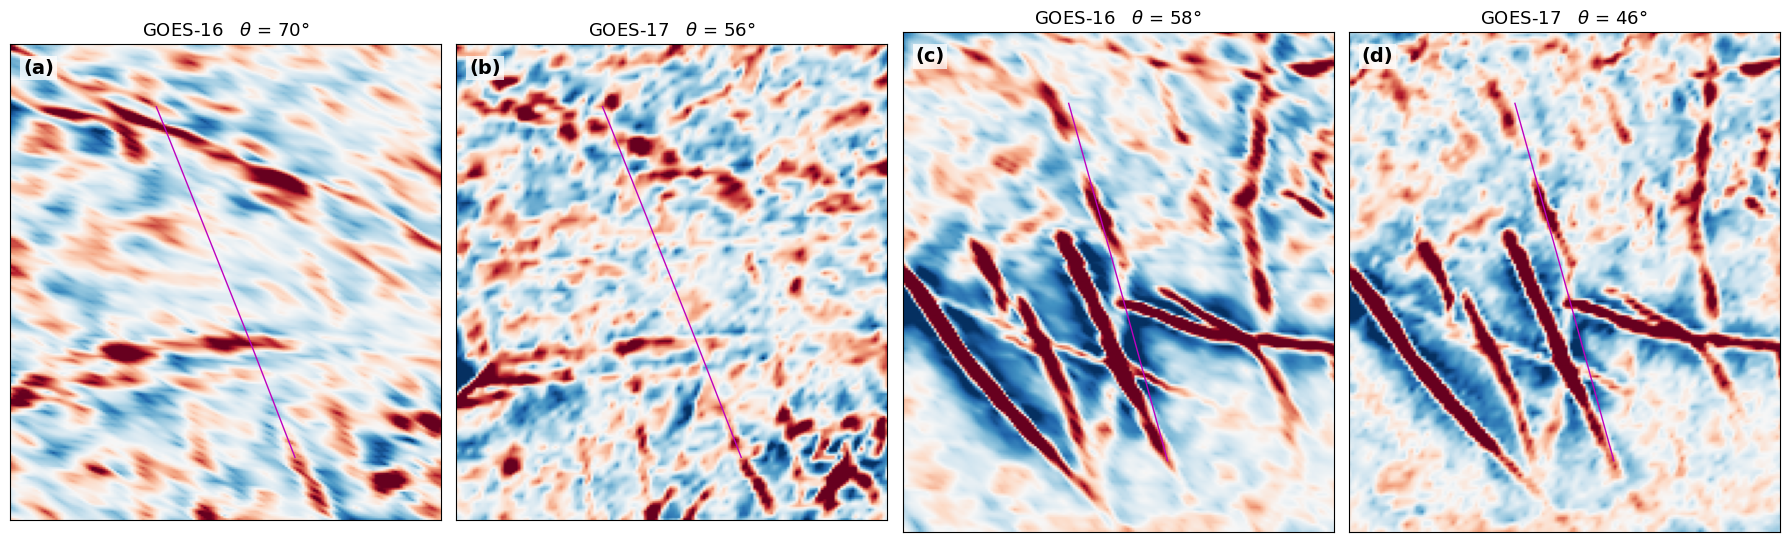

In [11]:
def vza_exhibit(si_bad, si_good, base_fs=13, save=None):
    """High-passed BTD from both satellites for a high-VZA scene (left pair)
    and a mid-domain scene (right pair)."""
    fig, axes = plt.subplots(1, 4, figsize=(18, 5.5))
    for r, si in enumerate((si_bad, si_good)):
        sd = load_scene(scenes.iloc[si], prof_df, cfg)
        rec, pr, ex = run_scene(sd, cfg, do_map=True)
        glat, glon = ex["glat"], ex["glon"]
        px = ((glat[-1,0]-glat[0,0])*111.0/glat.shape[0],
              (glon[0,-1]-glon[0,0])*111.0
              * np.cos(np.deg2rad(glat.mean()))/glat.shape[1])
        sig, _ = km_filters(px, cfg)
        h_ref = rec["h_local"] if np.isfinite(rec["h_local"]) else 11.0
        a, b = cfg.match_channels
        ext = [glon.min(), glon.max(), glat.min(), glat.max()]
        for c, sat in enumerate((cfg.sat_east, cfg.sat_west)):
            samp = make_sampler(sd.fields[sat][a], sd.fields[sat][b])
            ala, alo = apparent_surface_latlon(glat, glon, h_ref*1e3,
                                               SAT_LON[sat])
            F = hp_km(samp(ala, alo), sig)
            ax = axes[2*r + c]
            ax.imshow(F, origin="lower", cmap="RdBu_r", vmin=-1.5,
                      vmax=1.5, extent=ext)
            ax.plot(pr.lon, pr.lat, "m-", lw=1.0)
            vza = rec["vza_east"] if sat == cfg.sat_east else rec["vza_west"]
            ax.set_title(f"GOES-{sat}   $\\theta$ = {vza:.0f}\u00b0",
                         fontsize=base_fs)
            ax.text(0.03, 0.97, f"({'abcd'[2*r+c]})", transform=ax.transAxes,
                    fontsize=base_fs+1, fontweight="bold", va="top",
                    bbox=dict(fc="white", ec="none", alpha=0.75, pad=2))
            ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300); plt.close(fig)
    return fig

vza_exhibit(103, 8, save="/Users/lewisclark/Documents/python_work/stereo/outputs/fyr_vza_exhibit.pdf")

In [7]:
"""Configuration for contrailstereo"""

from __future__ import annotations

import hashlib
import json
from dataclasses import dataclass, field, asdict

# --- Geometry constants ---
# WGS84 ellipsoid and GOES orbit radius [m]
R_EQ    = 6378137.0
R_POL   = 6356752.31414
SAT_R   = 42164160.0

# Satellite longitudes [deg]
SAT_LON = {
    16: -75.2,
    17: -137.2,
    18: -137.9,
    19: -75.2
}

@dataclass(frozen=True)
class StereoConfig:
    # Satellites
    sat_east: int = 16
    sat_west: int = 17
    match_channels: tuple = (13, 15) # BTD pair used for matching
                                     # (14,15) = testing candidate
                                     # (13,15) = default candidate

    # Grid 
    px_km: float = 1.0
    max_npx: int = 750
    min_npx: int = 60
    pad_lat_deg: float = 0.30
    pad_lon_deg: float = 0.70

    # Filter parameters
    hp_sigma_km: float = 8.0
    win_km: float = 25.0

    # Height scan 
    h_lo_km: float = 0.0
    h_hi_km: float = 16.0
    dh_km: float = 0.25
    hmin_cirrus_km: float = 8.0
    edge_km: float = 1.0

    # Scene-mode window
    local_deg: float = 0.35
    scene_window_deg: float = 1.0

    # Quality control thresholds
    r_min: float = 0.2
    min_local_px: int = 30
    min_valid_frac: float = 0.5
    prominence: float = 0.03
    no_data_s: float = 120.0
    vza_max_deg: float = 65.0 

    # Striping
    stripe_nsig: float = 4.0
    stripe_dilate: int = 1
    stripe_mask_primary: bool = True  # To be tested

    # ERA5 advection (v3.2, might be removed/replaced in tracker)
    wind_min_offset_s: float = 2.0
    wind_levels: tuple = ("100", "125", "150", "175", "200",
                          "225", "250", "300", "350", "400")
    wind_sigma_base: float = 2.5        # m/s error floor at cruise
    wind_sigma_frac: float = 0.08       # + fraction of local speed
    wind_resid_max_km: float = 0.25     # residual displacement -> "offset"

    # Map mode
    map_r_min: float = 0.35            # per-pixel quality mask floor
    map_amp_min_k: float = 0.25
    map_gates: tuple = (0.5, 0.6, 0.7) # r_map thresholds for quality/coverage tradeoff

    # Paths
    goes_cache: str = "data/goes_cache"
    era5_cache: str = "data/era5_cache"

    def config_hash(self) -> str:
        """Short stable hash of all settings, for stamping into outputs"""
        blob = json.dumps(asdict(self), sort_keys=True, default=str)
        return hashlib.sha256(blob.encode()).hexdigest()[:10]
    

DEFAULT = StereoConfig()

from scipy.ndimage import gaussian_filter


In [8]:
def km_filters(px, cfg: StereoConfig = DEFAULT):
    """Per-axis filter sizes (pixels) from physical scales (km)."""
    sig = (cfg.hp_sigma_km / px[0], cfg.hp_sigma_km / px[1])
    win = (max(int(cfg.win_km / px[0]) | 1, 3),
           max(int(cfg.win_km / px[1]) | 1, 3))
    return sig, win

def hp_km(f, sig):
    """NaN-aware high pass"""

    f = np.asarray(f, float)
    m = np.isfinite(f)
    sm = gaussian_filter(np.where(m, f, 0.0), sig)
    nm = gaussian_filter(m.astype(float), sig)
    with np.errstate(invalid="ignore", divide="ignore"):
        sm = sm / nm
    out = f - sm
    out[~m] = np.nan
    return out


In [9]:
def vza_exhibit(si_bad, si_good, base_fs=11, save=None):
    fig, axes = plt.subplots(2, 2, figsize=(13, 6.5),
                             constrained_layout=True)
    im = None
    for r, si in enumerate((si_bad, si_good)):
        sd = load_scene(scenes.iloc[si], prof_df, cfg)
        rec, pr, ex = run_scene(sd, cfg, do_map=True)
        glat, glon = ex["glat"], ex["glon"]
        coslat = np.cos(np.deg2rad(glat.mean()))
        px = ((glat[-1,0]-glat[0,0])*111.0/glat.shape[0],
              (glon[0,-1]-glon[0,0])*111.0*coslat/glon.shape[1])
        sig, _ = km_filters(px, cfg)
        h_ref = rec["h_local"] if np.isfinite(rec["h_local"]) else 11.0
        a, b = cfg.match_channels
        ext = [glon.min(), glon.max(), glat.min(), glat.max()]

        # view crop: half the latitude range, centred -> 2:1 panels
        lat_c = 0.5*(glat.min()+glat.max())
        half  = 0.25*(glat.max()-glat.min())

        for c, sat in enumerate((cfg.sat_east, cfg.sat_west)):
            samp = make_sampler(sd.fields[sat][a], sd.fields[sat][b])
            ala, alo = apparent_surface_latlon(glat, glon, h_ref*1e3,
                                               SAT_LON[sat])
            F = hp_km(samp(ala, alo), sig)
            ax = axes[r, c]
            im = ax.imshow(F, origin="lower", cmap="RdBu_r", vmin=-1.5,
                           vmax=1.5, extent=ext, aspect=1.0/coslat)
            ax.plot(pr.lon, pr.lat, "m-", lw=1.0)
            ax.set_ylim(lat_c-half, lat_c+half)
            vza = rec["vza_east"] if sat==cfg.sat_east else rec["vza_west"]
            ax.text(0.012, 0.93, f"({'abcd'[2*r+c]})", transform=ax.transAxes,
                    fontsize=base_fs+1, fontweight="bold", va="top",
                    bbox=dict(fc="white", ec="none", alpha=0.8, pad=2))
            ax.text(0.988, 0.93, f"GOES-{sat}   $\\theta$ = {vza:.0f}\u00b0",
                    transform=ax.transAxes, fontsize=base_fs, ha="right",
                    va="top", bbox=dict(fc="white", ec="none", alpha=0.8, pad=2))
            ax.set_xticks([]); ax.set_yticks([])

    cb = fig.colorbar(im, ax=axes, location="right", shrink=0.85, pad=0.012)
    cb.set_label("High-pass filtered BTD [K]", fontsize=base_fs)
    if save:
        fig.savefig(save, dpi=300, bbox_inches="tight"); plt.close(fig)
    return fig

In [13]:
vza_exhibit(104, 8, save="/Users/lewisclark/Documents/python_work/stereo/outputs/fyr_vza_exhibit.pdf")

: 

: 

: 

In [12]:
def domain_sweep_plot(profile_csv, results_csv, vmaxes=np.arange(55, 73.1, 2.5),
                      base_fs=13, n_boot=1000, save=None):
    res = pd.read_csv(results_csv)
    res["vza_max"] = res[["vza_east", "vza_west"]].max(axis=1)
    pp = pd.read_csv(profile_csv).dropna(subset=["h_map"])
    pp = pp.merge(res[["scene", "vza_max"]], on="scene")
    gated = pp[pp.r_map > 0.6]
    n_all = len(gated)

    xs, rs, los, his, frac = [], [], [], [], []
    for vm in vmaxes:
        q = gated[gated.vza_max <= vm]
        if q.scene.nunique() < 10:
            continue
        cv = bias_correct_cv(q.assign(r_map=1.0), gate=0.0)
        lo, hi = bias_correct_cv_ci(q.assign(r_map=1.0), gate=0.0,
                                    n_boot=n_boot)
        xs.append(vm); rs.append(cv["rmse_cv_corrected"])
        los.append(lo); his.append(hi)
        frac.append(len(q) / n_all)          # profiles, matching the left axis

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    c1, c2 = "#1f77b4", "#d95f02"

    # domain limits
    for x, lab in ((65, "inner domain"), (73, "outer domain")):
        ax.axvline(x, color="0.35", ls=":", lw=1.4, zorder=1)
        ax.annotate(lab, xy=(x, 1.0), xycoords=("data", "axes fraction"),
                    xytext=(-4, -6), textcoords="offset points",
                    fontsize=base_fs-3, color="0.35", va="top", ha="right",
                    rotation=90)

    ax.fill_between(xs, los, his, color=c1, alpha=0.15, lw=0)
    ax.plot(xs, rs, "o-", color=c1, lw=1.8, ms=6, zorder=3)
    ax.set_xlabel("Maximum viewing zenith angle of the pair [\u00b0]",
                  fontsize=base_fs)
    ax.set_ylabel("Bias-corrected RMSE [km]", fontsize=base_fs, color=c1)
    ax.tick_params(labelsize=base_fs-2)
    ax.tick_params(axis="y", labelcolor=c1)

    ax2 = ax.twinx()
    ax2.plot(xs, frac, "s--", color=c2, lw=1.8, ms=6)
    ax2.set_ylabel("Fraction of profiles retained", fontsize=base_fs, color=c2)
    ax2.tick_params(axis="y", labelcolor=c2, labelsize=base_fs-2)
    ax2.set_ylim(0, 1.02)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300); plt.close(fig)
    return fig

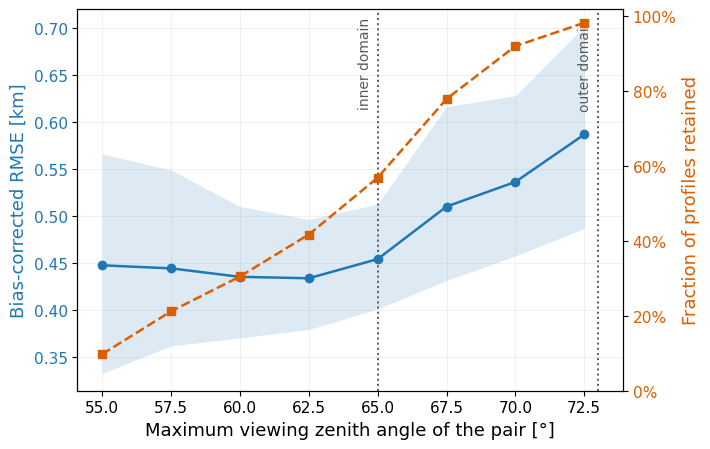

In [13]:
domain_sweep_plot("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv","/Users/lewisclark/Documents/python_work/stereo/outputs/results_1315.csv",save="/Users/lewisclark/Documents/python_work/stereo/outputs/fyr_VZA.pdf")

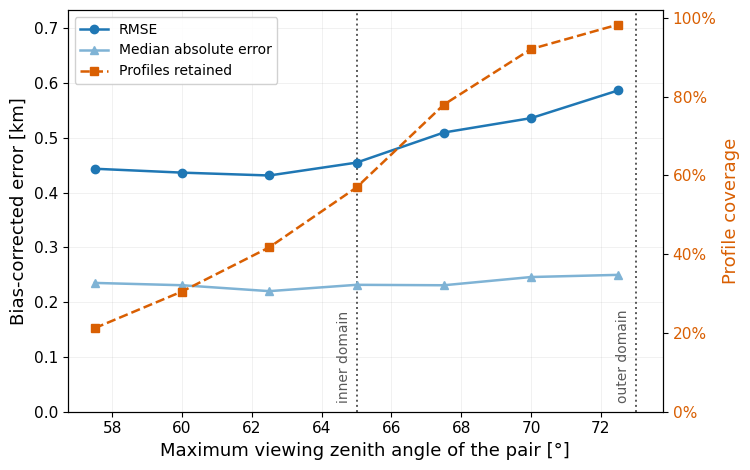

In [20]:
def domain_sweep_plot(profile_csv, results_csv,
                      vmaxes=np.arange(57.5, 73.1, 2.5),
                      base_fs=13, save=None):
    res = pd.read_csv(results_csv)
    res["vza_max"] = res[["vza_east", "vza_west"]].max(axis=1)
    pp = pd.read_csv(profile_csv).dropna(subset=["h_map"])
    pp = pp.merge(res[["scene", "vza_max"]], on="scene")
    gated = pp[pp.r_map > 0.6]
    n_all = len(gated)

    def loo_resid(q):
        e = (q.h_map - q.top_km).values
        sc = q.scene.values
        tot, cnt = e.sum(), len(e)
        out = np.empty_like(e)
        for s in np.unique(sc):
            m = sc == s
            out[m] = e[m] - (tot - e[m].sum()) / (cnt - m.sum())
        return out

    xs, rs, med, frac = [], [], [], []
    for vm in vmaxes:
        q = gated[gated.vza_max <= vm]
        if q.scene.nunique() < 10:
            continue
        r = loo_resid(q)
        xs.append(vm)
        rs.append(np.sqrt((r ** 2).mean()))
        med.append(np.median(np.abs(r)))
        frac.append(len(q) / n_all)

    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    c1, c2, c3 = "#1f77b4", "#7fb3d5", "#d95f02"

    for x, lab in ((65, "inner domain"), (73, "outer domain")):
        ax.axvline(x, color="0.35", ls=":", lw=1.4, zorder=1)
        ax.annotate(lab, xy=(x, 0.0), xycoords=("data", "axes fraction"),
                    xytext=(-4, 6), textcoords="offset points",
                    fontsize=base_fs-3, color="0.35",
                    va="bottom", ha="right", rotation=90)

    ax.plot(xs, rs, "o-", color=c1, lw=1.8, ms=6, zorder=3, label="RMSE")
    ax.plot(xs, med, "^-", color=c2, lw=1.8, ms=6, zorder=3,
            label="Median absolute error")
    ax.set_ylim(0, max(rs) * 1.25)
    ax.set_xlabel("Maximum viewing zenith angle of the pair [\u00b0]",
                  fontsize=base_fs)
    ax.set_ylabel("Bias-corrected error [km]", fontsize=base_fs)
    ax.tick_params(labelsize=base_fs-2)

    ax2 = ax.twinx()
    ax2.plot(xs, frac, "s--", color=c3, lw=1.8, ms=6,
             label="Profiles retained")
    ax2.set_ylabel("Profile coverage", fontsize=base_fs,
                   color=c3)
    ax2.tick_params(axis="y", labelcolor=c3, labelsize=base_fs-2)
    ax2.set_ylim(0, 1.02)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=base_fs-3, loc="upper left",
              framealpha=0.9)

    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300); plt.close(fig)
    return fig

domain_sweep_plot("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv","/Users/lewisclark/Documents/python_work/stereo/outputs/results_1315.csv",save="/Users/lewisclark/Documents/python_work/stereo/outputs/fyr_VZA.pdf")

In [21]:
import numpy as np
import pandas as pd


def loo_residuals(q, hcol="h_map", tcol="top_km", scol="scene"):
    """Per-profile errors with a leave-one-scene-out constant removed."""
    e = (q[hcol] - q[tcol]).values
    sc = q[scol].values
    tot, cnt = e.sum(), len(e)
    out = np.empty_like(e, dtype=float)
    for s in np.unique(sc):
        m = sc == s
        out[m] = e[m] - (tot - e[m].sum()) / (cnt - m.sum())
    return out


def within_between(q, hcol="h_map", tcol="top_km", scol="scene",
                   min_n=2, n_boot=1000, seed=0):
    """Split per-profile error into within-scene scatter and between-scene
    offset spread, both in km, such that within^2 + between^2 = total^2.

    within  : profile-to-profile scatter about each scene's own mean error
              -- matching precision inside a scene
    between : spread of scene mean errors about the overall mean
              -- scene-to-scene variation in what level the match locks to
    """
    q = q.copy()
    q["_e"] = loo_residuals(q, hcol, tcol, scol)
    g = q.groupby(scol)["_e"]
    n = g.count()
    keep = n[n >= min_n].index
    q = q[q[scol].isin(keep)]
    g = q.groupby(scol)["_e"]
    n, mu = g.count(), g.mean()

    total = np.sqrt((q["_e"] ** 2).mean())
    # pooled within-scene variance, weighted by profiles per scene
    within = np.sqrt(np.average(g.var(ddof=0), weights=n))
    # profile-weighted spread of scene means about the pooled mean
    grand = np.average(mu, weights=n)
    between = np.sqrt(np.average((mu - grand) ** 2, weights=n))

    # bootstrap over SCENES, since profiles within a scene are not independent
    rng = np.random.default_rng(seed)
    scenes = mu.index.values
    bw, bb = [], []
    for _ in range(n_boot):
        pick = rng.choice(scenes, len(scenes), replace=True)
        sub = pd.concat([q[q[scol] == s] for s in pick])
        gg = sub.groupby(sub[scol])["_e"]
        nn, mm = gg.count(), gg.mean()
        bw.append(np.sqrt(np.average(gg.var(ddof=0), weights=nn)))
        gr = np.average(mm, weights=nn)
        bb.append(np.sqrt(np.average((mm - gr) ** 2, weights=nn)))

    return dict(
        n_profiles=len(q), n_scenes=len(keep),
        total_km=total, within_km=within, between_km=between,
        within_ci=tuple(np.percentile(bw, [2.5, 97.5])),
        between_ci=tuple(np.percentile(bb, [2.5, 97.5])),
        between_share=between ** 2 / (within ** 2 + between ** 2),
        check_km=np.sqrt(within ** 2 + between ** 2),
    )


if __name__ == "__main__":
    import sys
    res = pd.read_csv(sys.argv[2])
    res["vza_max"] = res[["vza_east", "vza_west"]].max(axis=1)
    pp = pd.read_csv(sys.argv[1]).dropna(subset=["h_map"])
    pp = pp.merge(res[["scene", "vza_max"]], on="scene")
    pp = pp[pp.r_map > 0.6]

    for label, sub in [("full domain", pp),
                       ("inner domain", pp[pp.vza_max <= 65])]:
        d = within_between(sub)
        print(f"\n{label}: {d['n_profiles']} profiles, {d['n_scenes']} scenes")
        print(f"  total    {d['total_km']:.3f} km")
        print(f"  within   {d['within_km']:.3f} km  "
              f"[{d['within_ci'][0]:.3f}, {d['within_ci'][1]:.3f}]")
        print(f"  between  {d['between_km']:.3f} km  "
              f"[{d['between_ci'][0]:.3f}, {d['between_ci'][1]:.3f}]")
        print(f"  between accounts for {100*d['between_share']:.0f}% "
              f"of the error variance")
        print(f"  check: sqrt(w^2+b^2) = {d['check_km']:.3f} "
              f"vs total {d['total_km']:.3f}")

KeyError: "None of [Index(['vza_east', 'vza_west'], dtype='object')] are in the [columns]"

In [36]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",   # matches Times closely for the θ in vza_exhibit
    "mathtext.default": "it",
    "axes.unicode_minus": False,  # STIX lacks U+2212; avoids missing-glyph boxes
})

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from mpl_toolkits.axes_grid1 import make_axes_locatable


def _nice_bar_km(span_km):
    target = span_km / 4.0
    for c in (10, 20, 25, 50, 100, 200, 250, 500, 1000):
        if c >= target:
            return c
    return 1000


def map_panel(extras, pr, rec, scene_idx, btd=None, save=None,
              diagnostic_title=False, base_fs=11, h_lims=(10.0, 15.0),
              panel_labels=True, track_pad=0.12, scale_bar=True,
              legend_lat=33.2, cbar_width="4.5%", cbar_pad=0.08):
    """Publication figure: BTD + stereo height + peak correlation maps over
    the along-track comparison with CALIOP.

    h_lims      -> fixed colour range for the height map. Narrower shows more
                   structure; pixels outside are drawn saturated and the
                   colourbar grows extend arrows to say so.
    legend_lat  -> latitude the panel (d) legend is centred above.
    """
    glat, glon = extras["glat"], extras["glon"]
    Hq, rmax = extras["Hq"], extras["rmax"]
    if Hq is None:
        return None

    ext = [glon.min(), glon.max(), glat.min(), glat.max()]
    prs = pr.sort_values("lat")
    south, north = prs.iloc[0], prs.iloc[-1]

    h_min, h_max = float(np.nanmin(Hq)), float(np.nanmax(Hq))
    if h_lims is None:
        pad = 0.03 * (h_max - h_min + 1e-9)
        h_lims = (h_min - pad, h_max + pad)

    fig = plt.figure(figsize=(13, 8.5))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 1.0], hspace=0.28)
    map_axes = []

    panels = [(btd, "RdBu_r", None, "BTD [K]"),
              (Hq, "viridis", h_lims, "Stereo height [km]"),
              (rmax, "magma", (0, 0.9), "Peak correlation")]

    for k, (Z, cm, vl, cblabel) in enumerate(panels):
        ax = fig.add_subplot(gs[0, k])
        map_axes.append(ax)

        if Z is not None:
            if vl is None:
                vl = (np.nanpercentile(Z, 2), np.nanpercentile(Z, 98))
            below = bool(np.any(Z < vl[0]))
            above = bool(np.any(Z > vl[1]))
            extend = ("both" if (below and above)
                      else "min" if below else "max" if above else "neither")

            im = ax.imshow(Z, origin="lower", cmap=cm,
                           vmin=vl[0], vmax=vl[1], extent=ext)

            # colourbar height locked to the image, not the figure row
            cax = make_axes_locatable(ax).append_axes(
                "right", size=cbar_width, pad=cbar_pad)
            cb = plt.colorbar(im, cax=cax, extend=extend)
            cb.set_label(cblabel, fontsize=base_fs)
            cb.ax.tick_params(labelsize=base_fs - 1)

        ax.plot(pr.lon, pr.lat, "-", color="magenta", lw=1.2)
        ax.plot(south.lon, south.lat, "v", color="lime", ms=8, mec="k",
                mew=0.9, zorder=5)
        ax.plot(north.lon, north.lat, "^", color="orange", ms=8, mec="k",
                mew=0.9, zorder=5)

        if scale_bar and k == 0:
            km_per_deg_lon = 111.0 * np.cos(np.deg2rad(np.mean(ext[2:])))
            bar_km = _nice_bar_km((ext[1] - ext[0]) * km_per_deg_lon)
            bar_deg = bar_km / km_per_deg_lon
            x0 = ext[0] + 0.06 * (ext[1] - ext[0])
            y0 = ext[2] + 0.07 * (ext[3] - ext[2])
            ax.plot([x0, x0 + bar_deg], [y0, y0], "-", color="k", lw=2.5,
                    solid_capstyle="butt", zorder=6)
            ax.text(x0 + bar_deg / 2, y0 + 0.025 * (ext[3] - ext[2]),
                    f"{bar_km:g} km", ha="center", va="bottom",
                    fontsize=base_fs - 2, zorder=6,
                    bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

        if panel_labels:
            ax.text(0.03, 0.97, f"({'abc'[k]})", transform=ax.transAxes,
                    fontsize=base_fs + 1, fontweight="bold", va="top",
                    bbox=dict(fc="white", ec="none", alpha=0.75, pad=2))

        ax.set_xticks([]); ax.set_yticks([])
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

    # ---------------- along-track panel ----------------
    ax = fig.add_subplot(gs[1, :])
    ax.plot(pr.lat, pr.top_km, ".", color="magenta", ms=6,
            label="CALIOP cloud top")
    stack = [np.asarray(pr.top_km, float)]
    if "h_map" in pr:
        ax.plot(pr.lat, pr.h_map, ".", color="C0", ms=6,
                label="Stereo height")
        stack.append(np.asarray(pr.h_map, float))

    vals = np.concatenate(stack)
    vals = vals[np.isfinite(vals)]
    lo, hi = vals.min(), vals.max()
    pad = track_pad * (hi - lo + 1e-9)
    ax.set_ylim(lo - pad, hi + pad)

    tr = blended_transform_factory(ax.transData, ax.transAxes)
    for pt, mk, c in ((south, "v", "lime"), (north, "^", "orange")):
        ax.axvline(pt.lat, color=c, lw=0.9, alpha=0.5)
        ax.plot(pt.lat, 0.0, mk, color=c, ms=9, mec="k", mew=0.9,
                transform=tr, clip_on=False, zorder=5)

    ax.set_xlabel("Latitude along track [\u00b0N]   "
                  "(\u25bc southern end, \u25b2 northern end)",
                  fontsize=base_fs)
    ax.set_ylabel("Height [km]", fontsize=base_fs)
    ax.tick_params(labelsize=base_fs - 1)
    ax.grid(alpha=0.25, lw=0.5)

    # legend centred above the requested latitude
    xa, xb = ax.get_xlim()
    frac = float(np.clip((legend_lat - xa) / (xb - xa), 0.08, 0.92))
    ax.legend(fontsize=base_fs - 1, loc="lower center",
              bbox_to_anchor=(frac, 0.01), bbox_transform=ax.transAxes,
              framealpha=0.9, markerscale=1.6, borderpad=0.5)

    if panel_labels:
        ax.text(0.012, 0.95, "(d)", transform=ax.transAxes,
                fontsize=base_fs + 1, fontweight="bold", va="top")
    if diagnostic_title:
        ax.set_title(f"scene {scene_idx}: map_n={rec['map_n']}  "
                     f"map_bias={rec['map_bias']:+.2f}  qc={rec['qc']}",
                     fontsize=base_fs - 3)

    fig.tight_layout()
    fig.canvas.draw()                      # settle aspect-equal boxes first
    x0 = min(a.get_position().x0 for a in map_axes)
    x1 = max(a.get_position().x1 for a in map_axes)
    b = ax.get_position()
    ax.set_position([x0, b.y0, x1 - x0, b.height])

    if save:
        fig.savefig(save, dpi=300, bbox_inches=None)

    clipped = float(np.mean((Hq < h_lims[0]) | (Hq > h_lims[1])))
    info = {
        "h_field_min_km": h_min,
        "h_field_max_km": h_max,
        "colourbar_km": (float(h_lims[0]), float(h_lims[1])),
        "frac_pixels_outside_colourbar": clipped,
        "track_ylim_km": tuple(float(v) for v in ax.get_ylim()),
        "masked_frac": float(np.isnan(Hq).mean()),
    }
    return fig, info

/var/folders/nn/tkh6wftx1t12mxv0pzk9jkd00000gn/T/ipykernel_41613/2483239819.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


h_field_min_km       8.157930640842718
h_field_max_km       15.837587134938996
colourbar_km         (10.0, 15.0)
frac_pixels_outside_colourbar 0.004087471898630697
track_ylim_km        (11.252586206776552, 13.497413793223448)
masked_frac          0.20462906192519925


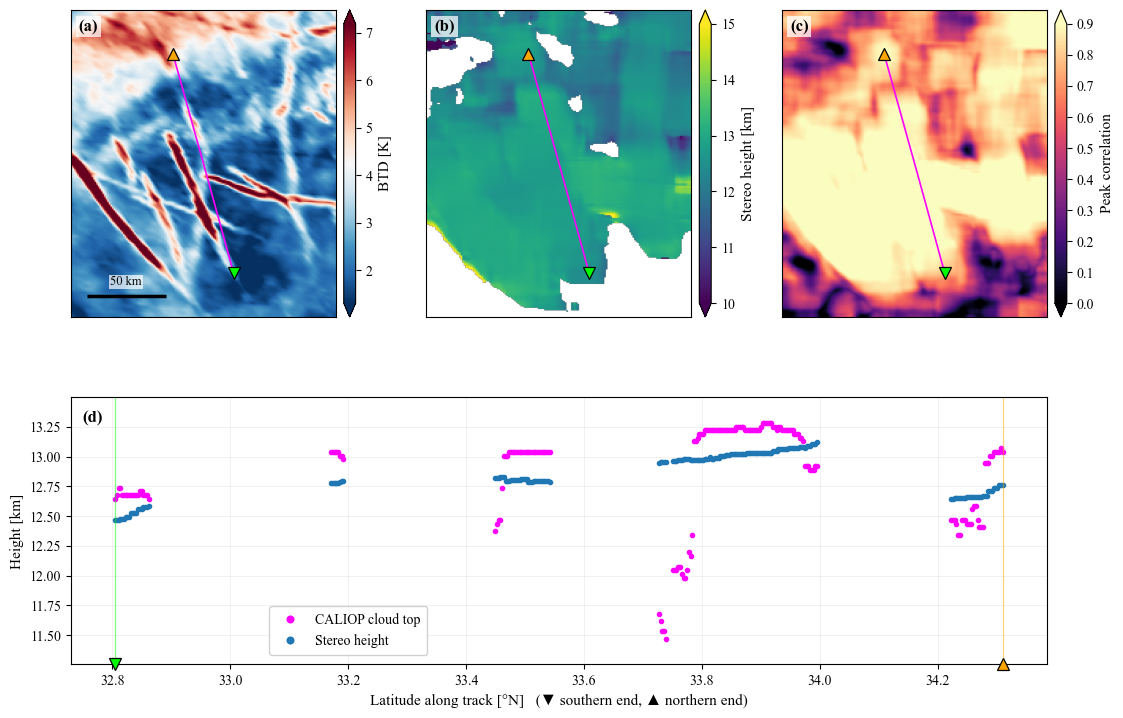

In [40]:
SCENE = 8   # the 1 Dec 2019 Southern California outbreak

sd = load_scene(scenes.iloc[SCENE], prof_df, cfg)
rec, pr, ex = run_scene(sd, cfg, do_map=True)

# BTD field on the common grid, parallax-corrected to the scene height
a, b = cfg.match_channels
h_ref = rec["h_local"] if np.isfinite(rec["h_local"]) else 11.0
samp = make_sampler(sd.fields[cfg.sat_east][a], sd.fields[cfg.sat_east][b])
ala, alo = apparent_surface_latlon(ex["glat"], ex["glon"], h_ref * 1e3,
                                   SAT_LON[cfg.sat_east])
btd = samp(ala, alo)

fig, info = map_panel(
    ex, pr, rec, SCENE, btd=btd,
    h_lims=(10.0, 15.0),
    legend_lat=33.2,
    base_fs=11,
    save="/Users/lewisclark/Documents/python_work/stereo/outputs/fyr_scene0_panel.pdf",
)

for k, v in info.items():
    print(f"{k:20s} {v}")